# Проект 3 — подробная учебная версия

Ниже сначала идёт подробный разбор логики, формул и типичных ошибок. После него — исполняемый notebook с кодом и результатами.

## Полный разбор

# Проект 3 — подробный разбор решения

## 0. Что требуется сделать

В приложении для знакомств тестируют новую цену премиум-подписки. Для новых
пользователей из части стран и при оплате через новые платёжные системы цена
обычной подписки изменилась. Цена пробного периода не менялась.

Нужно ответить на главный вопрос:

> Успешен ли эксперимент в целом? Можно ли раскатывать новую цену на всех?

В данных есть три независимые группы:

- `control_1` — первая контрольная группа;
- `control_2` — вторая контрольная группа;
- `test` — пользователи, увидевшие новую цену.

Главное правило: мы сравниваем **пользователей**, а не строки транзакций. Один
пользователь может купить несколько раз, но в эксперименте он должен иметь один
вес.

---

## 1. Какие файлы даны

Есть шесть CSV:

| Таблица | Содержание |
|---|---|
| `users_control_1.csv` | пользователи первой контрольной группы |
| `users_control_2.csv` | пользователи второй контрольной группы |
| `users_test.csv` | пользователи тестовой группы |
| `transactions_control_1.csv` | покупки первой контрольной группы |
| `transactions_control_2.csv` | покупки второй контрольной группы |
| `transactions_test.csv` | покупки тестовой группы |

В `users` одна строка соответствует пользователю. В `transactions` одна строка
соответствует покупке или операции.

Для основной выручки нужны поля:

- `uid` — идентификатор пользователя;
- `group` — контроль или тест;
- `total_revenue` — общая выручка пользователя;
- `product_type` — тип операции;
- `revenue` — сумма отдельной операции.

---

## 2. Импорт библиотек

```python
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
```

### Зачем каждая библиотека

- `Path` — аккуратно собирает пути к файлам;
- `pandas` — читает CSV, объединяет таблицы и считает метрики;
- `matplotlib` и `seaborn` — строят графики;
- `scipy.stats` — статистические тесты для средних и баланса групп;
- `statsmodels` — z-тест для долей и доверительные интервалы;
- `CompareMeans` — интервал разницы средних при t-тесте Уэлча.

В репозитории путь относительный:

```python
DATA_DIR = Path("../data/raw")
ALPHA = 0.05
```

`ALPHA = 0.05` означает, что различие считаем статистически значимым, если
`p-value < 0.05`.

---

## 3. Загрузка файлов

Каждый файл читаем отдельно, потому что у каждой группы свой файл.

```python
users_control_1 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_1.csv",
    sep=";",
)

users_control_2 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_2.csv",
    sep=";",
)

users_test = pd.read_csv(
    DATA_DIR / "Проект_3_users_test.csv",
    sep=";",
)
```

То же делаем для трёх транзакционных таблиц.

Параметр `sep=";"` обязателен: исходные файлы разделены точкой с запятой, а не
запятой. Если поставить неправильный разделитель, весь CSV может прочитаться в
один столбец.

---

## 4. Добавление групп

В исходных CSV название группы не всегда хранится отдельным столбцом, поэтому мы
добавляем его сами:

```python
users_control_1["group"] = "control_1"
users_control_2["group"] = "control_2"
users_test["group"] = "test"
```

Теперь однотипные таблицы можно объединить вертикально:

```python
users = pd.concat(
    [users_control_1, users_control_2, users_test],
    ignore_index=True,
)
```

`concat` складывает строки друг под друга. `ignore_index=True` создаёт новый
последовательный индекс.

Транзакции объединяем аналогично. После этого у нас есть одна таблица всех
пользователей и одна таблица всех операций.

---

## 5. Проверка качества данных

До расчёта статистики нельзя сразу строить метрики. Сначала нужно понять,
насколько источнику можно доверять.

### 5.1 Пропуски `uid`

В `transactions_control_1` есть 630 строк без пользователя. Такие строки нельзя
соединить с таблицей пользователей. Оставляем только записи с известным `uid`:

```python
transactions_valid = transactions.dropna(subset=["uid"]).copy()
transactions_valid["uid"] = transactions_valid["uid"].astype("int64")
```

Почему удаляем только строки без `uid`, а не все строки с пропусками? Потому что
часть остальных полей может быть пустой по смыслу, а пользователь всё ещё
определён.

### 5.2 Приведение `payment_id`

```python
transactions_valid["payment_id"] = (
    transactions_valid["payment_id"].astype("int64")
)
```

Важно не написать `paymnet_id`: это опечатка создаст новый столбец и оставит
оригинальный `payment_id` без изменений.

### 5.3 Дубли

Проверяем точные повторы:

```python
transactions_valid[
    transactions_valid["group"] == "control_1"
].duplicated().sum()
```

Повтор строки не обязательно означает техническую ошибку. Пользователь мог
несколько раз купить одинаковый пакет. Поэтому нельзя автоматически делать:

```python
transactions_valid = transactions_valid.drop_duplicates()
```

Сначала нужно сравнить сумму транзакций с `users.total_revenue`.

### 5.4 Reconciliation выручки

Сначала суммируем транзакции по пользователю:

```python
transaction_revenue = transactions_valid.groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    transactions_revenue=("revenue", "sum"),
)
```

Затем присоединяем сумму к `users` и считаем разницу:

```python
revenue_check = users[
    ["group", "uid", "total_revenue"]
].merge(
    transaction_revenue,
    on=["group", "uid"],
    how="left",
)

revenue_check["transactions_revenue"] = (
    revenue_check["transactions_revenue"].fillna(0)
)

revenue_check["difference"] = (
    revenue_check["transactions_revenue"]
    - revenue_check["total_revenue"]
)
```

В этом проекте есть локальные расхождения. Поэтому для общей выручки и ARPU
используем `users.total_revenue` как готовый пользовательский источник, а
транзакции используем для определения продукта и анализа цены.

### 5.5 Даты

Если прочитать даты обычным `pd.to_datetime`, часть оплат окажется раньше
регистрации. Это признак смешанного формата или ошибок в исходных временных
метках.

Поэтому даты не используем как фильтр экспериментальной популяции. Группы уже
заданы в `users`, и фильтрация по повреждённым датам могла бы удалить реальные
покупки.

---

## 6. Почему основной анализ на уровне пользователя

Плохой вариант:

```python
transactions_valid.groupby("group")["revenue"].mean()
```

Так мы сравниваем среднюю операцию, а не средний результат пользователя.
Покупатель с пятью платежами влияет на результат в пять раз сильнее.

Правильный вариант: сначала агрегировать продуктовые покупки по `group, uid`:

```python
premium_by_user = transactions_valid[
    transactions_valid["product_type"] == "premium_no_trial"
].groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    premium_revenue=("revenue", "sum"),
)
```

После этого присоединяем результат к `users`:

```python
experiment = users.merge(
    premium_by_user,
    on=["group", "uid"],
    how="left",
)

experiment["premium_revenue"] = (
    experiment["premium_revenue"].fillna(0)
)
experiment["payer"] = experiment["total_revenue"] > 0
experiment["premium_buyer"] = experiment["premium_revenue"] > 0
```

`LEFT JOIN` сохраняет пользователей, которые не покупали. Если использовать
`inner`, останутся только плательщики и конверсия станет завышенной.

---

## 7. Баланс групп

До оценки эффекта проверяем, похожи ли группы по признакам, существовавшим до
эксперимента: страна, пол, возраст, просмотры, коэффициент привлекательности.

### Категориальные признаки

Для страны и пола используем хи-квадрат:

```python
country_table = pd.crosstab(
    experiment["group"],
    experiment["country"],
)

country_test = stats.chi2_contingency(country_table)
country_test.pvalue
```

Нулевая гипотеза: распределение признака одинаково в группах.

### Числовые признаки

Для возраста и просмотров используем Краскела—Уоллиса:

```python
age_test = stats.kruskal(
    experiment.loc[experiment["group"] == "control_1", "age"],
    experiment.loc[experiment["group"] == "control_2", "age"],
    experiment.loc[experiment["group"] == "test", "age"],
)
```

Этот тест не требует нормального распределения и сравнивает несколько групп.

В проект 3 по проверенным признакам значимых различий не найдено. Это не
доказывает идеальную случайность, но делает сравнение более убедительным.

---

## 8. A/A-проверка контрольных групп

У нас две контрольные группы. До объединения проверяем `control_1` против
`control_2`:

- CR payer;
- CR premium;
- ARPU;
- ARPU обычного премиума.

Если между контролями есть значимое отличие, объединять их нельзя: сначала нужно
разобраться с причиной. В нашем случае значимых различий нет, поэтому объединяем:

```python
experiment["comparison"] = experiment["group"].replace(
    {
        "control_1": "control",
        "control_2": "control",
    }
)
```

После pooling контрольная выборка больше, а стандартная ошибка обычно меньше.

---

## 9. Метрики и формулы

### CR payer

```text
CR payer = платящие пользователи / все пользователи
```

В Pandas:

```python
конверсия = experiment.groupby("group")["payer"].mean()
```

### CR premium

```text
CR premium = покупатели premium_no_trial / все пользователи
```

### ARPU

```text
ARPU = общая выручка / все пользователи
```

Важный момент: нулевые пользователи должны оставаться в знаменателе.

### ARPPU

```text
ARPPU = общая выручка / платящие пользователи
```

ARPPU — диагностическая метрика. Она отвечает на вопрос «сколько приносит один
платящий», но не показывает, сколько пользователей мы потеряли.

### Trial CR

Поскольку цена `trial_premium` не менялась, эта метрика служит проверкой: не
произошло ли общего сбоя в оплате или привлечении пользователей.

---

## 10. Графики

Графики нужны не вместо статистики, а для быстрой проверки направления эффекта.

```python
metrics_plot["конверсия"].plot.bar()
```

На графике конверсии ось начинаем с нуля. Иначе небольшая разница визуально
может выглядеть огромной.

Для денежных метрик отдельно строим ARPU и ARPU обычного премиума. Так видно, что тестовый
ARPU немного выше, но одного визуального роста недостаточно для решения.

---

## 11. Проверка конверсий через z-тест

Для payer CR:

```python
payer_z, payer_p = proportions_ztest(
    [
        test_group["payer"].sum(),
        control_group["payer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)
```

Первый список содержит число успехов, второй — размеры групп. Нельзя передать
проценты вместо количества плательщиков.

Аналогично проверяем `premium_buyer` и `trial_buyer`.

### Доверительный интервал разницы долей

Раньше его можно было считать вручную через стандартную ошибку, но это легко
испортить знаками `+` и `-`. Надёжнее использовать библиотеку:

```python
payer_interval = confint_proportions_2indep(
    test_group["payer"].sum(),
    len(test_group),
    control_group["payer"].sum(),
    len(control_group),
    method="wald",
)
```

Порядок важен: функция возвращает интервал для `test - control`. Если весь
интервал ниже нуля, тест хуже контроля по конверсии.

---

## 12. Проверка ARPU через t-тест Уэлча

```python
arpu_test = stats.ttest_ind(
    test_group["total_revenue"],
    control_group["total_revenue"],
    equal_var=False,
)
```

`equal_var=False` означает t-тест Уэлча. Это разумно, потому что выручка обычно
имеет разные дисперсии и длинный хвост.

Доверительный интервал разницы средних:

```python
arpu_interval = CompareMeans(
    DescrStatsW(test_group["total_revenue"]),
    DescrStatsW(control_group["total_revenue"]),
).tconfint_diff(usevar="unequal")
```

Если интервал включает ноль, статистически значимого отличия средних нет.

---

## 13. Таблица результатов

Для аккуратной итоговой таблицы сначала убеждаемся, что нужные колонки созданы:

```python
comparison_metrics = pooled_metrics.set_index("comparison").copy()

comparison_metrics["конверсия"] = (
    comparison_metrics["payers"]
    / comparison_metrics["users"]
)

comparison_metrics["premium_конверсия"] = (
    comparison_metrics["premium_buyers"]
    / comparison_metrics["users"]
)

comparison_metrics["trial_конверсия"] = (
    comparison_metrics["trial_buyers"]
    / comparison_metrics["users"]
)
```

Если обратиться к несуществующей колонке, например `premium_конверсия` до её
создания, Pandas выдаст `KeyError`. Поэтому сначала считаем столбец, затем
выбираем его через `.loc`.

Абсолютный и относительный эффекты:

```python
results["absolute_effect"] = (
    results["test"] - results["control"]
)

results["relative_effect_pct"] = (
    results["test"] / results["control"] - 1
) * 100
```

Нельзя писать `- 100`: это будет вычитание ста процентных пунктов, а не перевод
доли в проценты.

---

## 14. Как интерпретировать результат проект 3

Получились такие значения:

| Метрика | Контроль | Тест | Эффект |
|---|---:|---:|---:|
| CR payer | 4.40% | 3.39% | −1.02 п.п. |
| CR premium | 2.34% | 1.56% | −0.78 п.п. |
| ARPU | 523.21 | 534.08 | +2.08% |
| ARPU обычного премиума | 177.13 | 188.19 | +6.24% |

Статистические результаты:

- payer CR: `p = 0.0059` — снижение значимо;
- premium CR: `p = 0.0033` — снижение значимо;
- ARPU: `p = 0.9070` — рост не подтверждён;
- ARPU обычного премиума: `p = 0.8117` — рост не подтверждён;
- trial CR: `p = 0.9228` — различий нет.

### Почему итог — «не раскатывать»

Цена подняла средний чек у части купивших, но покупателей стало меньше. При
этом основной денежный показатель ARPU статистически не вырос. Значит, текущий
вариант цены не доказал пользу для бизнеса.

---

## 15. Типичные ошибки

### Ошибка 1. Считать среднее по транзакциям

Это нарушает единицу анализа. Сначала агрегируй покупки до пользователя.

### Ошибка 2. Удалить всех пользователей без оплаты

Так исчезает правильный знаменатель CR и ARPU.

### Ошибка 3. Сделать `inner merge`

`inner` выбросит пользователей без совпадения. Для экспериментальной базы нужен
`left merge` от таблицы пользователей.

### Ошибка 4. Считать успехом только рост ARPPU

ARPPU считается после отбора плательщиков и может скрыть падение конверсии.

### Ошибка 5. Удалить все дубли транзакций

Повторная покупка может быть реальной. Сначала нужна сверка с
`total_revenue`.

### Ошибка 6. Фильтровать по повреждённым датам

В проект 3 даты дают невозможную хронологию при обычном разборе дат. Пока формат
не исправлен, не используем его для отбора пользователей.

### Ошибка 7. Перепутать знак эффекта

В этой работе эффект считается как `test - control`. Отрицательный эффект CR
означает, что тест хуже контроля.

### Ошибка 8. Путать `p-value` и размер эффекта

`p-value` отвечает на вопрос «насколько результат совместим со случайностью».
Размер эффекта отвечает на вопрос «насколько велика разница». Для решения нужны
оба показателя.

---

## 16. Как рассказать решение на защите

Короткая последовательность ответа:

1. «Я анализировал эксперимент на уровне пользователя, потому что транзакций у
   одного `uid` может быть несколько».
2. «Сначала проверил качество данных: пропуски, дубли, расхождение выручки и
   даты».
3. «Проверил баланс групп и A/A-контроль, после чего объединил два контроля».
4. «Основные метрики — payer CR, premium CR и ARPU; ARPPU использовал как
   диагностическую».
5. «Для долей применил z-тест пропорций, для средних — t-тест Уэлча».
6. «CR значимо снизился, ARPU не вырос значимо, поэтому новую цену не
   раскатываем».
7. «Следующий шаг — протестировать меньший рост цены и дольше наблюдать LTV,
   повторные платежи и отток».



## Исполняемая часть

Далее запускается тот же анализ сверху вниз: загрузка данных, проверки, метрики, тесты и финальная рекомендация.

# A/B-тест цены премиум-подписки

## Краткий вывод

### A/B-тест новой цены премиум-подписки

В этой версии код идёт линейно сверху вниз: **без собственных функций и
без циклов**. Мы:

1. загружаем шесть файлов;
2. проверяем ошибки и расхождения;
3. собираем таблицу уровня пользователя;
4. проверяем баланс и две контрольные группы;
5. считаем продуктовые метрики;
6. проверяем статистическую значимость;
7. проверяем устойчивость денежных выводов к крупным выручкам;
8. принимаем бизнес-решение.

**Главный вывод:** эксперимент нельзя считать успешным. Рост цены поднял
выручку на одного платящего, но значимо снизил конверсию. `ARPU` не вырос
статистически значимо, поэтому раскатывать новую цену на всех не стоит.

Подробный учебный разбор каждого шага находится в `../docs/project_3_step_by_step_explanation.md`.

## 1. Что проверяем

В тестовой группе изменилась цена премиум-подписки для части новых
пользователей из нескольких стран и платёжных систем. Цена пробного
периода не менялась.

Единица анализа — **пользователь**, а не отдельная транзакция.

Основные метрики:

- `CR payer` — доля пользователей с любой оплатой;
- `CR premium` — доля пользователей, купивших `premium_no_trial`;
- `ARPU` — общая выручка на одного пользователя;
- `ARPU обычного премиума` — выручка от обычного премиума на пользователя;
- `ARPPU` — выручка на одного платящего, вспомогательная метрика;
- `CR trial` — конверсия в пробный премиум, цена которого не менялась.

Уровень значимости: `alpha = 0.05`.

## 2. Импорт библиотек

Используем готовые инструменты:

- `pandas` — таблицы и расчёты;
- `matplotlib` и `seaborn` — графики;
- `scipy` и `statsmodels` — статистические тесты.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")
ALPHA = 0.05

## 3. Загрузка шести файлов

Таблицы `users` содержат всех участников эксперимента. Таблицы
`transactions` содержат только покупки.

In [2]:
users_control_1 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_1.csv",
    sep=";",
)
users_control_2 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_2.csv",
    sep=";",
)
users_test = pd.read_csv(
    DATA_DIR / "Проект_3_users_test.csv",
    sep=";",
)

transactions_control_1 = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_control_1.csv",
    sep=";",
)
transactions_control_2 = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_control_2.csv",
    sep=";",
)
transactions_test = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_test.csv",
    sep=";",
)

print("users_control_1:", users_control_1.shape)
print("users_control_2:", users_control_2.shape)
print("users_test:", users_test.shape)
print()
print("transactions_control_1:", transactions_control_1.shape)
print("transactions_control_2:", transactions_control_2.shape)
print("transactions_test:", transactions_test.shape)

users_control_1: (4340, 13)
users_control_2: (4264, 13)
users_test: (4308, 13)

transactions_control_1: (1007, 8)
transactions_control_2: (328, 8)
transactions_test: (273, 8)


## 4. Добавляем названия групп

После этого можно объединить однотипные файлы в две таблицы.

In [3]:
users_control_1["group"] = "control_1"
users_control_2["group"] = "control_2"
users_test["group"] = "test"

transactions_control_1["group"] = "control_1"
transactions_control_2["group"] = "control_2"
transactions_test["group"] = "test"

users = pd.concat(
    [users_control_1, users_control_2, users_test],
    ignore_index=True,
)

transactions = pd.concat(
    [
        transactions_control_1,
        transactions_control_2,
        transactions_test,
    ],
    ignore_index=True,
)

users.shape, transactions.shape

((12912, 14), (1608, 9))

## 5. Проверка качества данных

Сначала смотрим на пропуски `uid` и точные повторы строк.

В `transactions_control_1` есть 630 служебных строк без пользователя и
большинства бизнес-полей. Их нельзя связать с участниками эксперимента,
поэтому удаляем только эти строки.

In [4]:
quality = pd.DataFrame(
    {
        "file": [
            "transactions_control_1",
            "transactions_control_2",
            "transactions_test",
        ],
        "rows": [
            len(transactions_control_1),
            len(transactions_control_2),
            len(transactions_test),
        ],
        "missing_uid": [
            transactions_control_1["uid"].isna().sum(),
            transactions_control_2["uid"].isna().sum(),
            transactions_test["uid"].isna().sum(),
        ],
        "exact_duplicates_all_rows": [
            transactions_control_1.duplicated().sum(),
            transactions_control_2.duplicated().sum(),
            transactions_test.duplicated().sum(),
        ],
    }
)

quality

,file,rows,missing_uid,exact_duplicates_all_rows
0,transactions_control_1,1007,630,650
1,transactions_control_2,328,0,5
2,transactions_test,273,0,7


In [5]:
transactions_valid = transactions.dropna(subset=["uid"]).copy()
transactions_valid["uid"] = transactions_valid["uid"].astype("int64")
transactions_valid["payment_id"] = (
    transactions_valid["payment_id"].astype("int64")
)

duplicate_check = pd.DataFrame(
    {
        "group": ["control_1", "control_2", "test"],
        "valid_rows": [
            len(
                transactions_valid[
                    transactions_valid["group"] == "control_1"
                ]
            ),
            len(
                transactions_valid[
                    transactions_valid["group"] == "control_2"
                ]
            ),
            len(
                transactions_valid[
                    transactions_valid["group"] == "test"
                ]
            ),
        ],
        "exact_duplicates": [
            transactions_valid[
                transactions_valid["group"] == "control_1"
            ].duplicated().sum(),
            transactions_valid[
                transactions_valid["group"] == "control_2"
            ].duplicated().sum(),
            transactions_valid[
                transactions_valid["group"] == "test"
            ].duplicated().sum(),
        ],
    }
)

duplicate_check

,group,valid_rows,exact_duplicates
0,control_1,377,21
1,control_2,328,5
2,test,273,7


In [6]:
transaction_links = transactions_valid[
    ["group", "uid"]
].merge(
    users[["group", "uid"]].drop_duplicates(),
    on=["group", "uid"],
    how="left",
    indicator=True,
)

print(
    "Транзакций без пользователя в своей группе:",
    (transaction_links["_merge"] == "left_only").sum(),
)

Транзакций без пользователя в своей группе: 0


### Почему не удаляем все одинаковые транзакции

Одинаковые строки не обязательно являются техническими дублями:
пользователь мог несколько раз купить одинаковый пакет. Поэтому
сверяем сумму транзакций с готовым `total_revenue` из таблицы
пользователей.

Если бездумно вызвать `drop_duplicates()`, даже полностью совпадающая
контрольная группа перестанет сходиться по выручке. Поэтому:

- `total_revenue` используем как источник общей выручки;
- транзакции используем для определения типа покупки;
- точные повторы не удаляем автоматически.

In [7]:
transaction_revenue = transactions_valid.groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    transactions_revenue=("revenue", "sum"),
)

revenue_check = users[
    ["group", "uid", "total_revenue"]
].merge(
    transaction_revenue,
    on=["group", "uid"],
    how="left",
)

revenue_check["transactions_revenue"] = (
    revenue_check["transactions_revenue"].fillna(0)
)
revenue_check["difference"] = (
    revenue_check["transactions_revenue"]
    - revenue_check["total_revenue"]
)
revenue_check["mismatch"] = revenue_check["difference"].ne(0)

reconciliation = revenue_check.groupby(
    "group",
    as_index=False,
).agg(
    users_revenue=("total_revenue", "sum"),
    transactions_revenue=("transactions_revenue", "sum"),
    mismatch_users=("mismatch", "sum"),
)

reconciliation["difference"] = (
    reconciliation["transactions_revenue"]
    - reconciliation["users_revenue"]
)

reconciliation

,group,users_revenue,transactions_revenue,mismatch_users,difference
0,control_1,2581267,"2,612,311.0000",2,"31,044.0000"
1,control_2,1920438,"1,920,438.0000",0,0.0000
2,test,2300818,"2,344,901.0000",1,"44,083.0000"


Расхождения локальные:

- `control_2` сходится полностью;
- в `control_1` транзакции выше `total_revenue` на 31 044;
- в `test` транзакции выше `total_revenue` на 44 083.

Поэтому для `ARPU`, `ARPPU` и общей конверсии берём
`users.total_revenue`. Это защищает результат от ошибочных операций в
журнале транзакций.

### Дополнительная проблема с датами

Если разобрать строки как обычный формат `YYYY-MM-DD`, часть оплат
окажется раньше регистрации. Это указывает на смешанный порядок месяца
и дня или на ошибки в исходных временных метках.

Мы не фильтруем эксперимент по этим датам: состав групп уже задан в
`users`, а фильтр по повреждённому времени мог бы удалить реальные
покупки.

In [8]:
date_check = transactions_valid[
    ["group", "joined_at", "paid_at"]
].copy()

date_check["joined_default"] = pd.to_datetime(
    date_check["joined_at"],
    errors="coerce",
)
date_check["paid_default"] = pd.to_datetime(
    date_check["paid_at"],
    errors="coerce",
)
date_check["paid_before_joined"] = (
    date_check["paid_default"] < date_check["joined_default"]
)

date_check.groupby("group", as_index=False).agg(
    transactions=("paid_before_joined", "size"),
    paid_before_joined=("paid_before_joined", "sum"),
)

,group,transactions,paid_before_joined
0,control_1,377,55
1,control_2,328,60
2,test,273,47


## 6. Собираем таблицу уровня пользователя

Для каждого пользователя создаём четыре признака:

- `payer` — была ли любая оплата;
- `premium_buyer` — покупался ли обычный премиум;
- `premium_revenue` — выручка от обычного премиума;
- `trial_buyer` — покупался ли пробный премиум.

Перед объединением транзакции агрегируются до уровня пользователя, чтобы
повторные покупки не размножили строки.

In [9]:
premium_by_user = transactions_valid[
    transactions_valid["product_type"] == "premium_no_trial"
].groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    premium_revenue=("revenue", "sum"),
    premium_transactions=("revenue", "size"),
)

trial_by_user = transactions_valid[
    transactions_valid["product_type"] == "trial_premium"
][["group", "uid"]].drop_duplicates()

trial_by_user["trial_buyer"] = True

experiment = users.merge(
    premium_by_user,
    on=["group", "uid"],
    how="left",
)

experiment = experiment.merge(
    trial_by_user,
    on=["group", "uid"],
    how="left",
)

experiment["premium_revenue"] = (
    experiment["premium_revenue"].fillna(0)
)
experiment["premium_transactions"] = (
    experiment["premium_transactions"].fillna(0)
)
experiment["payer"] = experiment["total_revenue"] > 0
experiment["premium_buyer"] = experiment["premium_revenue"] > 0
experiment["trial_buyer"] = experiment["trial_buyer"].eq(True)

print("Строк в users:", len(users))
print("Строк в experiment:", len(experiment))
print("Повторяющихся uid внутри группы:", experiment.duplicated(["group", "uid"]).sum())

Строк в users: 12912
Строк в experiment: 12912
Повторяющихся uid внутри группы: 0


## 7. Проверяем баланс групп

До проверки результата убеждаемся, что группы похожи по признакам,
которые существовали до оплаты.

- для категорий используем критерий хи-квадрат;
- для числовых признаков — критерий Краскела—Уоллиса.

Если `p-value > 0.05`, значимых различий не обнаружено.

In [10]:
country_test = stats.chi2_contingency(
    pd.crosstab(experiment["group"], experiment["country"])
)
gender_test = stats.chi2_contingency(
    pd.crosstab(experiment["group"], experiment["gender"])
)

age_test = stats.kruskal(
    experiment.loc[experiment["group"] == "control_1", "age"],
    experiment.loc[experiment["group"] == "control_2", "age"],
    experiment.loc[experiment["group"] == "test", "age"],
)
attraction_test = stats.kruskal(
    experiment.loc[
        experiment["group"] == "control_1",
        "attraction_coeff",
    ],
    experiment.loc[
        experiment["group"] == "control_2",
        "attraction_coeff",
    ],
    experiment.loc[
        experiment["group"] == "test",
        "attraction_coeff",
    ],
)
views_test = stats.kruskal(
    experiment.loc[experiment["group"] == "control_1", "views_count"],
    experiment.loc[experiment["group"] == "control_2", "views_count"],
    experiment.loc[experiment["group"] == "test", "views_count"],
)

balance = pd.DataFrame(
    {
        "feature": [
            "country",
            "gender",
            "age",
            "attraction_coeff",
            "views_count",
        ],
        "p_value": [
            country_test.pvalue,
            gender_test.pvalue,
            age_test.pvalue,
            attraction_test.pvalue,
            views_test.pvalue,
        ],
    }
)

balance["significant_difference"] = balance["p_value"] < ALPHA
balance

,feature,p_value,significant_difference
0,country,0.6582,False
1,gender,0.5075,False
2,age,0.5740,False
3,attraction_coeff,0.8769,False
4,views_count,0.4555,False


Значимых различий по стране, полу, возрасту, коэффициенту
привлекательности и числу просмотров нет. Баланс рандомизации выглядит
приемлемо.

## 8. A/A-проверка двух контролей

До объединения `control_1` и `control_2` проверяем, не отличаются ли они
сами по себе.

- конверсии сравниваем z-тестом долей;
- среднюю выручку сравниваем t-тестом Уэлча.

In [11]:
control_1 = experiment[experiment["group"] == "control_1"]
control_2 = experiment[experiment["group"] == "control_2"]

aa_payer_z, aa_payer_p = proportions_ztest(
    [
        control_1["payer"].sum(),
        control_2["payer"].sum(),
    ],
    [
        len(control_1),
        len(control_2),
    ],
)

aa_premium_z, aa_premium_p = proportions_ztest(
    [
        control_1["premium_buyer"].sum(),
        control_2["premium_buyer"].sum(),
    ],
    [
        len(control_1),
        len(control_2),
    ],
)

aa_arpu = stats.ttest_ind(
    control_1["total_revenue"],
    control_2["total_revenue"],
    equal_var=False,
)

aa_premium_arpu = stats.ttest_ind(
    control_1["premium_revenue"],
    control_2["premium_revenue"],
    equal_var=False,
)

aa_results = pd.DataFrame(
    {
        "metric": [
            "CR payer",
            "CR premium",
            "ARPU",
            "Premium ARPU",
        ],
        "p_value": [
            aa_payer_p,
            aa_premium_p,
            aa_arpu.pvalue,
            aa_premium_arpu.pvalue,
        ],
    }
)

aa_results["significant_difference"] = aa_results["p_value"] < ALPHA
aa_results

,metric,p_value,significant_difference
0,CR payer,0.9308,False
1,CR premium,0.7332,False
2,ARPU,0.2628,False
3,Premium ARPU,0.9066,False


Все `p-value` выше 0.05. Статистических оснований считать две контрольные
группы разными нет, поэтому для основной проверки объединяем их. Так
контроль становится больше, а оценка — точнее.

## 9. Считаем метрики по трём группам

Формулы:

- `конверсия = payers / users`;
- `ARPU = revenue / users`;
- `ARPPU = revenue / payers`.

In [12]:
metrics = experiment.groupby(
    "group",
    as_index=False,
).agg(
    users=("uid", "size"),
    payers=("payer", "sum"),
    revenue=("total_revenue", "sum"),
    premium_buyers=("premium_buyer", "sum"),
    premium_revenue=("premium_revenue", "sum"),
    trial_buyers=("trial_buyer", "sum"),
)

metrics["conversion"] = metrics["payers"] / metrics["users"]
metrics["arpu"] = metrics["revenue"] / metrics["users"]
metrics["arppu"] = metrics["revenue"] / metrics["payers"]

metrics["premium_conversion"] = (
    metrics["premium_buyers"] / metrics["users"]
)
metrics["premium_arpu"] = (
    metrics["premium_revenue"] / metrics["users"]
)
metrics["premium_arppu"] = (
    metrics["premium_revenue"] / metrics["premium_buyers"]
)
metrics["trial_conversion"] = (
    metrics["trial_buyers"] / metrics["users"]
)

metrics

,group,users,payers,revenue,premium_buyers,premium_revenue,trial_buyers,conversion,arpu,arppu,premium_conversion,premium_arpu,premium_arppu,trial_conversion
0,control_1,4340,192,2581267,99,"779,259.0000",67,0.0442,594.7620,"13,444.0990",0.0228,179.5528,"7,871.3030",0.0154
1,control_2,4264,187,1920438,102,"744,809.0000",53,0.0439,450.3841,"10,269.7219",0.0239,174.6738,"7,302.0490",0.0124
2,test,4308,146,2300818,67,"810,706.0000",61,0.0339,534.0803,"15,759.0274",0.0156,188.1862,"12,100.0896",0.0142


## 10. Визуальное сравнение

Сначала сравним конверсии. Оси начинаются с нуля, поэтому разница не
преувеличена.

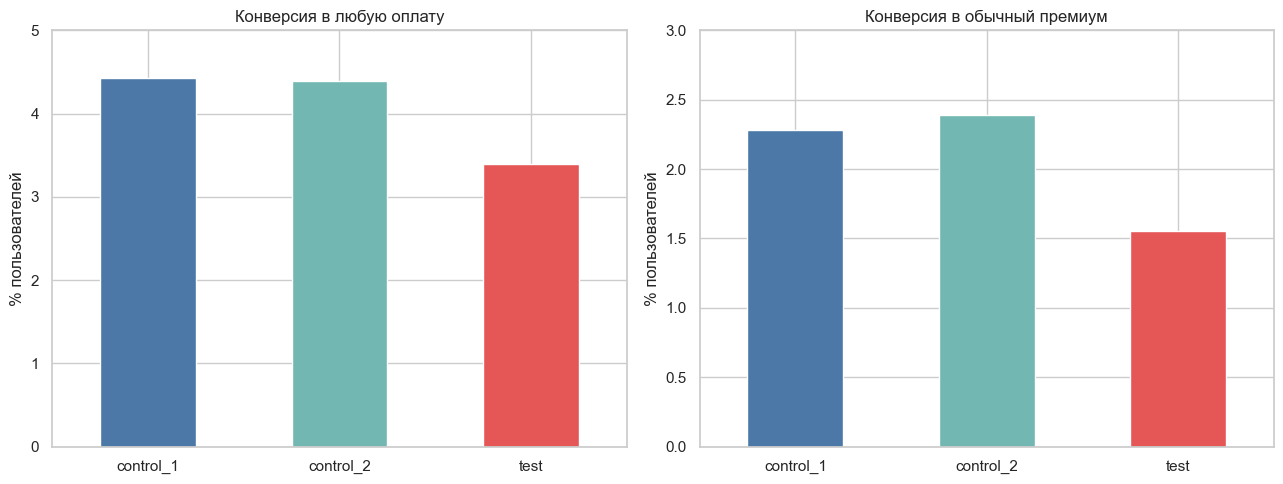

In [13]:
metrics_plot = metrics.set_index("group").loc[
    ["control_1", "control_2", "test"]
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

(metrics_plot["conversion"] * 100).plot.bar(
    ax=axes[0],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[0].set_title("Конверсия в любую оплату")
axes[0].set_xlabel("")
axes[0].set_ylabel("% пользователей")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, 5)

(metrics_plot["premium_conversion"] * 100).plot.bar(
    ax=axes[1],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[1].set_title("Конверсия в обычный премиум")
axes[1].set_xlabel("")
axes[1].set_ylabel("% пользователей")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 3)

plt.tight_layout()
plt.show()

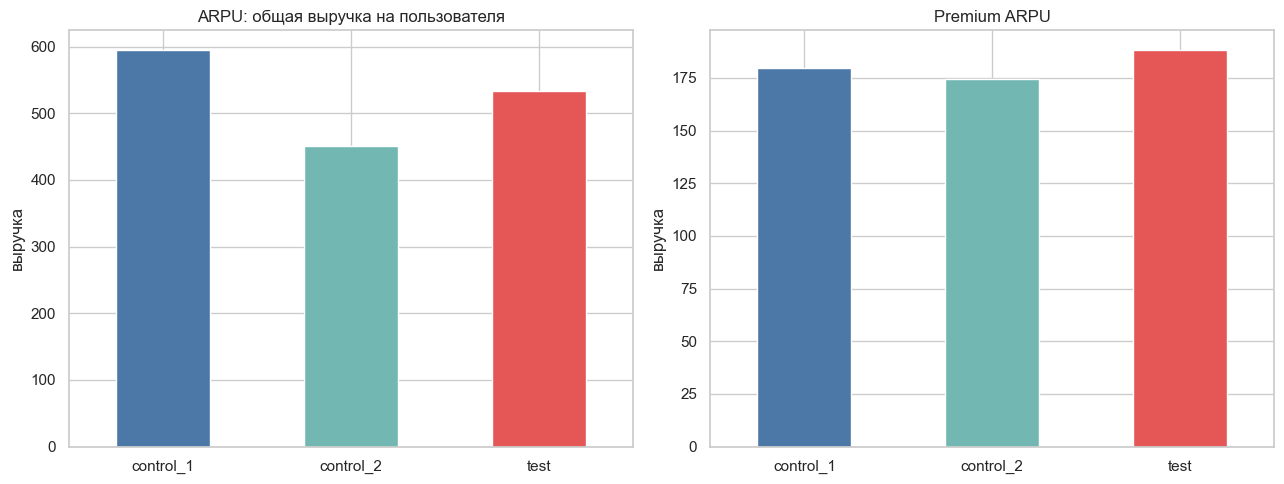

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_plot["arpu"].plot.bar(
    ax=axes[0],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[0].set_title("ARPU: общая выручка на пользователя")
axes[0].set_xlabel("")
axes[0].set_ylabel("выручка")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0)

metrics_plot["premium_arpu"].plot.bar(
    ax=axes[1],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[1].set_title("Premium ARPU")
axes[1].set_xlabel("")
axes[1].set_ylabel("выручка")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0)

plt.tight_layout()
plt.show()

По описательным метрикам видно:

- конверсия теста ниже;
- выручка на пользователя немного выше объединённого контроля;
- выручка на платящего выше, что логично при более высокой цене.

Но по одному графику нельзя решить, случайны различия или нет. Нужны
статистические тесты.

## 11. Объединяем контроли

In [15]:
experiment["comparison"] = experiment["group"].replace(
    {
        "control_1": "control",
        "control_2": "control",
    }
)

pooled_metrics = experiment.groupby(
    "comparison",
    as_index=False,
).agg(
    users=("uid", "size"),
    payers=("payer", "sum"),
    revenue=("total_revenue", "sum"),
    premium_buyers=("premium_buyer", "sum"),
    premium_revenue=("premium_revenue", "sum"),
    trial_buyers=("trial_buyer", "sum"),
)

pooled_metrics["conversion"] = (
    pooled_metrics["payers"] / pooled_metrics["users"]
)
pooled_metrics["arpu"] = (
    pooled_metrics["revenue"] / pooled_metrics["users"]
)
pooled_metrics["arppu"] = (
    pooled_metrics["revenue"] / pooled_metrics["payers"]
)
pooled_metrics["premium_conversion"] = (
    pooled_metrics["premium_buyers"] / pooled_metrics["users"]
)
pooled_metrics["premium_arpu"] = (
    pooled_metrics["premium_revenue"] / pooled_metrics["users"]
)
pooled_metrics["premium_arppu"] = (
    pooled_metrics["premium_revenue"]
    / pooled_metrics["premium_buyers"]
)
pooled_metrics["trial_conversion"] = (
    pooled_metrics["trial_buyers"] / pooled_metrics["users"]
)

pooled_metrics

,comparison,users,payers,revenue,premium_buyers,premium_revenue,trial_buyers,conversion,arpu,arppu,premium_conversion,premium_arpu,premium_arppu,trial_conversion
0,control,8604,379,4501705,201,"1,524,068.0000",120,0.0440,523.2107,"11,877.8496",0.0234,177.1348,"7,582.4279",0.0139
1,test,4308,146,2300818,67,"810,706.0000",61,0.0339,534.0803,"15,759.0274",0.0156,188.1862,"12,100.0896",0.0142


## 12. Проверка гипотез

Нулевые гипотезы:

- конверсии теста и контроля равны;
- средняя выручка на пользователя одинакова.

Альтернативные гипотезы: показатели отличаются.

Для конверсий используем z-тест, для средних — t-тест Уэлча. Дополнительно
считаем 95% доверительные интервалы разницы.

In [16]:
test_group = experiment[experiment["comparison"] == "test"]
control_group = experiment[experiment["comparison"] == "control"]

payer_z, payer_p = proportions_ztest(
    [
        test_group["payer"].sum(),
        control_group["payer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

premium_z, premium_p = proportions_ztest(
    [
        test_group["premium_buyer"].sum(),
        control_group["premium_buyer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

trial_z, trial_p = proportions_ztest(
    [
        test_group["trial_buyer"].sum(),
        control_group["trial_buyer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

arpu_test = stats.ttest_ind(
    test_group["total_revenue"],
    control_group["total_revenue"],
    equal_var=False,
)

premium_arpu_test = stats.ttest_ind(
    test_group["premium_revenue"],
    control_group["premium_revenue"],
    equal_var=False,
)

arpu_interval = CompareMeans(
    DescrStatsW(test_group["total_revenue"]),
    DescrStatsW(control_group["total_revenue"]),
).tconfint_diff(usevar="unequal")

premium_arpu_interval = CompareMeans(
    DescrStatsW(test_group["premium_revenue"]),
    DescrStatsW(control_group["premium_revenue"]),
).tconfint_diff(usevar="unequal")

In [17]:
test_cr = test_group["payer"].mean()
control_cr = control_group["payer"].mean()

test_premium_cr = test_group["premium_buyer"].mean()
control_premium_cr = control_group["premium_buyer"].mean()

payer_interval = confint_proportions_2indep(
    test_group["payer"].sum(),
    len(test_group),
    control_group["payer"].sum(),
    len(control_group),
    method="wald",
)

premium_interval = confint_proportions_2indep(
    test_group["premium_buyer"].sum(),
    len(test_group),
    control_group["premium_buyer"].sum(),
    len(control_group),
    method="wald",
)

In [18]:
test_arpu = test_group["total_revenue"].mean()
control_arpu = control_group["total_revenue"].mean()

test_premium_arpu = test_group["premium_revenue"].mean()
control_premium_arpu = control_group["premium_revenue"].mean()

test_trial_cr = test_group["trial_buyer"].mean()
control_trial_cr = control_group["trial_buyer"].mean()

results = pd.DataFrame(
    {
        "metric": [
            "CR payer, п.п.",
            "CR premium, п.п.",
            "ARPU",
            "Premium ARPU",
            "CR trial, п.п.",
        ],
        "control": [
            control_cr * 100,
            control_premium_cr * 100,
            control_arpu,
            control_premium_arpu,
            control_trial_cr * 100,
        ],
        "test": [
            test_cr * 100,
            test_premium_cr * 100,
            test_arpu,
            test_premium_arpu,
            test_trial_cr * 100,
        ],
        "absolute_effect": [
            (test_cr - control_cr) * 100,
            (test_premium_cr - control_premium_cr) * 100,
            test_arpu - control_arpu,
            test_premium_arpu - control_premium_arpu,
            (test_trial_cr - control_trial_cr) * 100,
        ],
        "relative_effect_pct": [
            (test_cr / control_cr - 1) * 100,
            (test_premium_cr / control_premium_cr - 1) * 100,
            (test_arpu / control_arpu - 1) * 100,
            (
                test_premium_arpu
                / control_premium_arpu
                - 1
            )
            * 100,
            (test_trial_cr / control_trial_cr - 1) * 100,
        ],
        "p_value": [
            payer_p,
            premium_p,
            arpu_test.pvalue,
            premium_arpu_test.pvalue,
            trial_p,
        ],
    }
)

results["significant"] = results["p_value"] < ALPHA
results

,metric,control,test,absolute_effect,relative_effect_pct,p_value,significant
0,"CR payer, п.п.",4.4049,3.3890,-1.0159,-23.0624,0.0059,True
1,"CR premium, п.п.",2.3361,1.5552,-0.7809,-33.4262,0.0033,True
2,ARPU,523.2107,534.0803,10.8696,2.0775,0.9070,False
3,Premium ARPU,177.1348,188.1862,11.0513,6.2389,0.8117,False
4,"CR trial, п.п.",1.3947,1.4160,0.0213,1.5251,0.9228,False


In [19]:
intervals = pd.DataFrame(
    {
        "metric": [
            "CR payer, п.п.",
            "CR premium, п.п.",
            "ARPU",
            "Premium ARPU",
        ],
        "ci_95_low": [
            payer_interval[0] * 100,
            premium_interval[0] * 100,
            arpu_interval[0],
            premium_arpu_interval[0],
        ],
        "ci_95_high": [
            payer_interval[1] * 100,
            premium_interval[1] * 100,
            arpu_interval[1],
            premium_arpu_interval[1],
        ],
    }
)

intervals

,metric,ci_95_low,ci_95_high
0,"CR payer, п.п.",-1.7087,-0.3231
1,"CR premium, п.п.",-1.2691,-0.2926
2,ARPU,-171.4166,193.1558
3,Premium ARPU,-79.9059,102.0086


### Интерпретация тестов

1. **Общая конверсия в оплату** снизилась с 4.40% до 3.39%:
   эффект `−1.02 п.п.` или примерно `−23%`, `p = 0.0059`.
2. **Конверсия в обычный премиум** снизилась с 2.34% до 1.56%:
   эффект `−0.78 п.п.` или примерно `−33%`, `p = 0.0033`.
3. **ARPU** вырос только на 2.1%, но результат незначим:
   `p = 0.907`, доверительный интервал включает и падение, и рост.
4. **ARPU обычного премиума** вырос на 6.2%, но тоже незначимо:
   `p = 0.812`.
5. **Конверсия в пробный премиум**, цена которого не менялась, почти
   одинакова: `p = 0.923`. Это полезная контрольная проверка.

## 13. Что произошло с выручкой на платящего

`ARPPU` считается только среди тех, кто уже оплатил. Эта группа
сформировалась после воздействия цены, поэтому `ARPPU` нельзя считать
главным критерием успеха. Но он помогает понять механику результата.

In [20]:
test_payers = test_group[
    test_group["payer"]
]["total_revenue"]
control_payers = control_group[
    control_group["payer"]
]["total_revenue"]

arppu_test = stats.ttest_ind(
    test_payers,
    control_payers,
    equal_var=False,
)

test_premium_buyers = test_group[
    test_group["premium_buyer"]
]["premium_revenue"]
control_premium_buyers = control_group[
    control_group["premium_buyer"]
]["premium_revenue"]

premium_arppu_test = stats.ttest_ind(
    test_premium_buyers,
    control_premium_buyers,
    equal_var=False,
)

arppu_results = pd.DataFrame(
    {
        "metric": ["ARPPU", "Premium ARPPU"],
        "control": [
            control_payers.mean(),
            control_premium_buyers.mean(),
        ],
        "test": [
            test_payers.mean(),
            test_premium_buyers.mean(),
        ],
        "relative_effect_pct": [
            (
                test_payers.mean()
                / control_payers.mean()
                - 1
            )
            * 100,
            (
                test_premium_buyers.mean()
                / control_premium_buyers.mean()
                - 1
            )
            * 100,
        ],
        "p_value": [
            arppu_test.pvalue,
            premium_arppu_test.pvalue,
        ],
    }
)

arppu_results

,metric,control,test,relative_effect_pct,p_value
0,ARPPU,"11,877.8496","15,759.0274",32.6758,0.0546
1,Premium ARPPU,"7,582.4279","12,100.0896",59.5807,0.0587


Выручка на платящего действительно выше, но оба `p-value` немного выше
0.05. Даже если бы рост `ARPPU` был значимым, он не отменял бы основной
результат: пользователей стало конвертироваться меньше, а `ARPU` не
вырос.

## 14. Чувствительность к крупным выручкам

T-тест Уэлча допускает ненормальность при больших выборках, но единичные
крупные значения могут сильно увеличить дисперсию и расширить доверительный
интервал. Поэтому дополнительно проводим **анализ чувствительности**.

Границу задаём заранее понятным и воспроизводимым правилом Тьюки на общей
выборке положительных выручек:

`верхняя граница = Q3 + 1.5 × IQR`.

Важно: это не новая основная выборка и не способ добиться маленького
`p-value`. Крупные покупки могли возникнуть из-за экспериментальной цены,
поэтому исходный анализ всех рандомизированных пользователей остаётся
главным, а отсечение показывает только устойчивость вывода.

In [21]:
positive_revenue = experiment.loc[
    experiment["total_revenue"] > 0,
    "total_revenue",
]

revenue_q1 = positive_revenue.quantile(0.25)
revenue_q3 = positive_revenue.quantile(0.75)
revenue_iqr = revenue_q3 - revenue_q1
revenue_cutoff = revenue_q3 + 1.5 * revenue_iqr

control_outliers = control_payers > revenue_cutoff
test_outliers = test_payers > revenue_cutoff

outlier_summary = pd.DataFrame(
    {
        "group": ["control", "test"],
        "payers": [len(control_payers), len(test_payers)],
        "outlier_payers": [control_outliers.sum(), test_outliers.sum()],
        "outlier_share_pct": [
            control_outliers.mean() * 100,
            test_outliers.mean() * 100,
        ],
        "outlier_revenue_share_pct": [
            control_payers[control_outliers].sum()
            / control_payers.sum()
            * 100,
            test_payers[test_outliers].sum()
            / test_payers.sum()
            * 100,
        ],
    }
)

print(f"Q1 = {revenue_q1:,.1f}")
print(f"Q3 = {revenue_q3:,.1f}")
print(f"IQR = {revenue_iqr:,.1f}")
print(f"Верхняя граница Тьюки = {revenue_cutoff:,.1f}")
outlier_summary

Q1 = 6,292.0
Q3 = 13,247.0
IQR = 6,955.0
Верхняя граница Тьюки = 23,679.5


,group,payers,outlier_payers,outlier_share_pct,outlier_revenue_share_pct
0,control,379,17,4.4855,26.7508
1,test,146,18,12.3288,39.3687


Получили границу **23 679.5**. Выше неё находятся 17 из 379
плательщиков контроля (4.49%) и 18 из 146 плательщиков теста (12.33%). На них
приходится 26.75% и 39.37% выручки плательщиков соответственно.

Доли крупных покупок различаются, поэтому удалять их из основного результата
нельзя: они могут быть частью эффекта новой цены. Ниже сравниваем полный и
очищенный варианты именно как проверку чувствительности.

In [22]:
control_trimmed = control_group[
    control_group["total_revenue"] <= revenue_cutoff
]["total_revenue"]
test_trimmed = test_group[
    test_group["total_revenue"] <= revenue_cutoff
]["total_revenue"]

control_payers_trimmed = control_payers[~control_outliers]
test_payers_trimmed = test_payers[~test_outliers]

raw_arpu_welch = stats.ttest_ind(
    test_group["total_revenue"],
    control_group["total_revenue"],
    equal_var=False,
)
trimmed_arpu_welch = stats.ttest_ind(
    test_trimmed,
    control_trimmed,
    equal_var=False,
)
raw_arppu_welch = stats.ttest_ind(
    test_payers,
    control_payers,
    equal_var=False,
)
trimmed_arppu_welch = stats.ttest_ind(
    test_payers_trimmed,
    control_payers_trimmed,
    equal_var=False,
)

raw_arpu_mw = stats.mannwhitneyu(
    test_group["total_revenue"],
    control_group["total_revenue"],
    alternative="two-sided",
)
trimmed_arpu_mw = stats.mannwhitneyu(
    test_trimmed,
    control_trimmed,
    alternative="two-sided",
)
raw_arppu_mw = stats.mannwhitneyu(
    test_payers,
    control_payers,
    alternative="two-sided",
)
trimmed_arppu_mw = stats.mannwhitneyu(
    test_payers_trimmed,
    control_payers_trimmed,
    alternative="two-sided",
)

sensitivity_results = pd.DataFrame(
    {
        "metric": ["ARPU", "ARPU", "ARPPU", "ARPPU"],
        "sample": ["all", "trimmed", "all", "trimmed"],
        "control_mean": [
            control_group["total_revenue"].mean(),
            control_trimmed.mean(),
            control_payers.mean(),
            control_payers_trimmed.mean(),
        ],
        "test_mean": [
            test_group["total_revenue"].mean(),
            test_trimmed.mean(),
            test_payers.mean(),
            test_payers_trimmed.mean(),
        ],
        "difference": [
            test_group["total_revenue"].mean()
            - control_group["total_revenue"].mean(),
            test_trimmed.mean() - control_trimmed.mean(),
            test_payers.mean() - control_payers.mean(),
            test_payers_trimmed.mean() - control_payers_trimmed.mean(),
        ],
        "welch_p_value": [
            raw_arpu_welch.pvalue,
            trimmed_arpu_welch.pvalue,
            raw_arppu_welch.pvalue,
            trimmed_arppu_welch.pvalue,
        ],
        "mann_whitney_p_value": [
            raw_arpu_mw.pvalue,
            trimmed_arpu_mw.pvalue,
            raw_arppu_mw.pvalue,
            trimmed_arppu_mw.pvalue,
        ],
    }
)

sensitivity_results

,metric,sample,control_mean,test_mean,difference,welch_p_value,mann_whitney_p_value
0,ARPU,all,523.2107,534.0803,10.8696,0.9070,0.0080
1,ARPU,trimmed,384.0064,325.1788,-58.8276,0.1286,0.0008
2,ARPPU,all,"11,877.8496","15,759.0274","3,881.1778",0.0546,0.0000
3,ARPPU,trimmed,"9,109.0138","10,898.5703","1,789.5565",0.0008,0.0004


In [23]:
BOOTSTRAP_ITERATIONS = 10_000
rng = np.random.default_rng(42)

raw_control_samples = rng.choice(
    control_payers.to_numpy(),
    size=(BOOTSTRAP_ITERATIONS, len(control_payers)),
    replace=True,
)
raw_test_samples = rng.choice(
    test_payers.to_numpy(),
    size=(BOOTSTRAP_ITERATIONS, len(test_payers)),
    replace=True,
)
raw_median_differences = (
    np.median(raw_test_samples, axis=1)
    - np.median(raw_control_samples, axis=1)
)
raw_median_ci = np.quantile(raw_median_differences, [0.025, 0.975])

trimmed_control_samples = rng.choice(
    control_payers_trimmed.to_numpy(),
    size=(BOOTSTRAP_ITERATIONS, len(control_payers_trimmed)),
    replace=True,
)
trimmed_test_samples = rng.choice(
    test_payers_trimmed.to_numpy(),
    size=(BOOTSTRAP_ITERATIONS, len(test_payers_trimmed)),
    replace=True,
)
trimmed_median_differences = (
    np.median(trimmed_test_samples, axis=1)
    - np.median(trimmed_control_samples, axis=1)
)
trimmed_median_ci = np.quantile(
    trimmed_median_differences,
    [0.025, 0.975],
)

bootstrap_medians = pd.DataFrame(
    {
        "sample": ["all", "trimmed"],
        "control_median": [
            control_payers.median(),
            control_payers_trimmed.median(),
        ],
        "test_median": [
            test_payers.median(),
            test_payers_trimmed.median(),
        ],
        "median_difference": [
            test_payers.median() - control_payers.median(),
            test_payers_trimmed.median()
            - control_payers_trimmed.median(),
        ],
        "bootstrap_ci_95_low": [
            raw_median_ci[0],
            trimmed_median_ci[0],
        ],
        "bootstrap_ci_95_high": [
            raw_median_ci[1],
            trimmed_median_ci[1],
        ],
    }
)

bootstrap_medians

,sample,control_median,test_median,median_difference,bootstrap_ci_95_low,bootstrap_ci_95_high
0,all,"9,087.0000","12,727.0000","3,640.0000","2,782.0000","4,797.0000"
1,trimmed,"9,087.0000","12,597.0000","3,510.0000",923.0000,"5,109.0000"


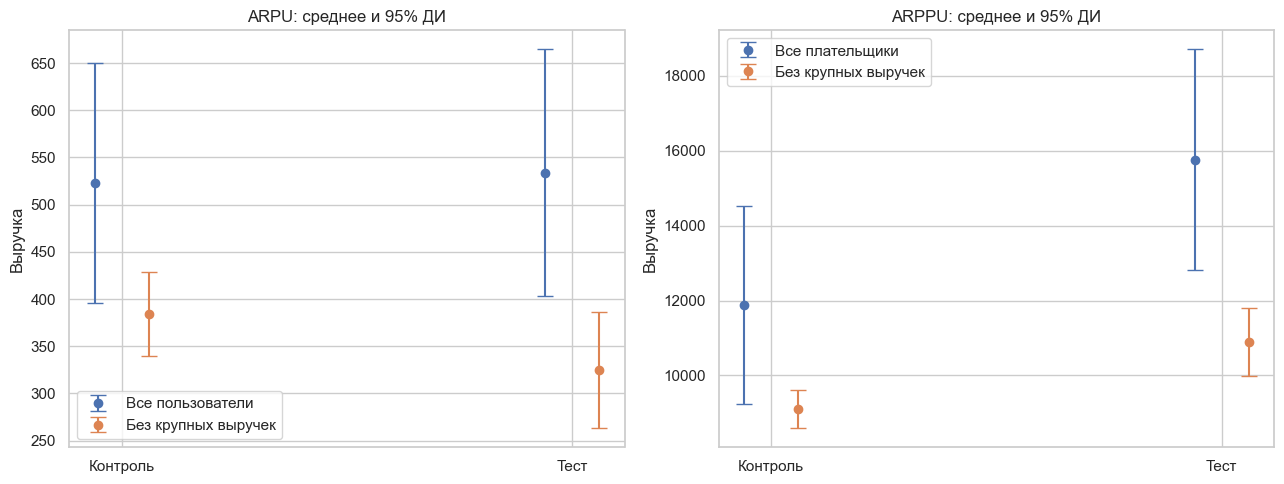

In [24]:
raw_arpu_control_ci = DescrStatsW(
    control_group["total_revenue"]
).tconfint_mean()
raw_arpu_test_ci = DescrStatsW(
    test_group["total_revenue"]
).tconfint_mean()
trimmed_arpu_control_ci = DescrStatsW(
    control_trimmed
).tconfint_mean()
trimmed_arpu_test_ci = DescrStatsW(
    test_trimmed
).tconfint_mean()

raw_arppu_control_ci = DescrStatsW(
    control_payers
).tconfint_mean()
raw_arppu_test_ci = DescrStatsW(
    test_payers
).tconfint_mean()
trimmed_arppu_control_ci = DescrStatsW(
    control_payers_trimmed
).tconfint_mean()
trimmed_arppu_test_ci = DescrStatsW(
    test_payers_trimmed
).tconfint_mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    [0, 1],
    [control_arpu, test_arpu],
    yerr=[
        [
            control_arpu - raw_arpu_control_ci[0],
            test_arpu - raw_arpu_test_ci[0],
        ],
        [
            raw_arpu_control_ci[1] - control_arpu,
            raw_arpu_test_ci[1] - test_arpu,
        ],
    ],
    fmt="o",
    capsize=6,
    label="Все пользователи",
)
axes[0].errorbar(
    [0.12, 1.12],
    [control_trimmed.mean(), test_trimmed.mean()],
    yerr=[
        [
            control_trimmed.mean() - trimmed_arpu_control_ci[0],
            test_trimmed.mean() - trimmed_arpu_test_ci[0],
        ],
        [
            trimmed_arpu_control_ci[1] - control_trimmed.mean(),
            trimmed_arpu_test_ci[1] - test_trimmed.mean(),
        ],
    ],
    fmt="o",
    capsize=6,
    label="Без крупных выручек",
)
axes[0].set(
    xticks=[0.06, 1.06],
    xticklabels=["Контроль", "Тест"],
    title="ARPU: среднее и 95% ДИ",
    ylabel="Выручка",
)
axes[0].legend()

axes[1].errorbar(
    [0, 1],
    [control_payers.mean(), test_payers.mean()],
    yerr=[
        [
            control_payers.mean() - raw_arppu_control_ci[0],
            test_payers.mean() - raw_arppu_test_ci[0],
        ],
        [
            raw_arppu_control_ci[1] - control_payers.mean(),
            raw_arppu_test_ci[1] - test_payers.mean(),
        ],
    ],
    fmt="o",
    capsize=6,
    label="Все плательщики",
)
axes[1].errorbar(
    [0.12, 1.12],
    [control_payers_trimmed.mean(), test_payers_trimmed.mean()],
    yerr=[
        [
            control_payers_trimmed.mean()
            - trimmed_arppu_control_ci[0],
            test_payers_trimmed.mean()
            - trimmed_arppu_test_ci[0],
        ],
        [
            trimmed_arppu_control_ci[1]
            - control_payers_trimmed.mean(),
            trimmed_arppu_test_ci[1]
            - test_payers_trimmed.mean(),
        ],
    ],
    fmt="o",
    capsize=6,
    label="Без крупных выручек",
)
axes[1].set(
    xticks=[0.06, 1.06],
    xticklabels=["Контроль", "Тест"],
    title="ARPPU: среднее и 95% ДИ",
    ylabel="Выручка",
)
axes[1].legend()

plt.tight_layout()
plt.show()

### Вывод по проверке устойчивости

- **ARPU на полных данных:** разница `+10.87`, t-тест Уэлча
  `p = 0.9070` — значимого роста нет.
- **ARPU после отсечения:** разница становится `−58.83`, но остаётся
  незначимой, `p = 0.1286`. Следовательно, успех по основной денежной
  метрике не подтверждается ни в одном варианте.
- **ARPPU на полных данных:** разница `+3 881.18`, `p = 0.0546`.
- **ARPPU после отсечения:** разница `+1 789.56`, t-тест Уэлча
  `p = 0.0008`; Манна—Уитни также показывает различие (`p = 0.0004`).
- Бутстрап разницы медиан ARPPU подтверждает сдвиг: на полных данных
  медианная разница `+3 640`, 95% ДИ `[2 782; 4 797]`; после отсечения
  `+3 510`, 95% ДИ `[923; 5 109]`.

После удаления крупных значений дисперсия ARPPU уменьшается, поэтому различие
средних становится статистически значимым. Однако бизнес-решение не меняется:
ARPPU — условная диагностическая метрика среди уже отобранных плательщиков,
тогда как ARPU на всех рандомизированных пользователях не вырос, а конверсия
значимо снизилась.

Манна—Уитни проверяет различие распределений/рангов, а не равенство средних.
Поэтому его `p-value` для ARPU не трактуем как доказательство роста ARPU.

## 15. Видно ли изменение цены в транзакциях

Для обычного премиума чаще всего используются `payment_id` 147 и 68.
В системе 147 медианная сумма теста выше. Система 68 содержит разные
локальные цены, поэтому там единый рост не виден.

Это описательная проверка. Мы не отбираем пользователей по факту
покупки: такой отбор возник бы уже после воздействия эксперимента.

In [25]:
premium_prices = transactions_valid[
    transactions_valid["product_type"] == "premium_no_trial"
]

price_by_payment = premium_prices.groupby(
    ["group", "payment_id"],
    as_index=False,
).agg(
    purchases=("uid", "size"),
    buyers=("uid", "nunique"),
    median_revenue=("revenue", "median"),
    mean_revenue=("revenue", "mean"),
)

price_by_payment[
    price_by_payment["payment_id"].isin([68, 147])
]

,group,payment_id,purchases,buyers,median_revenue,mean_revenue
1,control_1,68,16,15,"2,801.5000","2,676.3750"
2,control_1,147,88,85,"6,292.0000","8,224.1250"
4,control_2,68,14,14,"3,568.5000","5,040.2857"
5,control_2,147,92,88,"6,292.0000","7,277.4565"
7,test,68,12,8,"3,087.5000","4,252.0833"
8,test,147,63,59,"8,216.0000","11,912.1270"


In [26]:
country_prices = premium_prices[
    premium_prices["payment_id"] == 147
].copy()

country_prices["comparison"] = country_prices["group"].replace(
    {
        "control_1": "control",
        "control_2": "control",
    }
)

country_medians = country_prices.groupby(
    ["country", "comparison"]
)["revenue"].median().unstack()

country_buyers = country_prices.groupby(
    ["country", "comparison"]
)["uid"].nunique().unstack().fillna(0)

country_summary = country_medians.join(
    country_buyers,
    lsuffix="_median",
    rsuffix="_buyers",
)

country_summary = country_summary[
    (country_summary["control_buyers"] >= 2)
    & (country_summary["test_buyers"] >= 2)
].copy()

country_summary["price_ratio"] = (
    country_summary["test_median"]
    / country_summary["control_median"]
)

country_summary.sort_values(
    "price_ratio",
    ascending=False,
)

comparison,control_median,test_median,control_buyers,test_buyers,price_ratio
country,,,,,
Argentina,"6,292.0000","12,597.0000",10.0000,5.0000,2.0021
Israel,"6,292.0000","12,597.0000",12.0000,2.0000,2.0021
Italy,"6,422.0000","12,597.0000",14.0000,5.0000,1.9615
United Arab Emirates,"6,292.0000","9,217.0000",7.0000,6.0000,1.4649
United States of America,"6,292.0000","9,100.0000",52.0000,15.0000,1.4463
Canada,"6,292.0000","8,651.5000",3.0000,2.0000,1.3750
Chile,"6,292.0000","8,190.0000",10.0000,4.0000,1.3017
United Kingdom (Great Britain),"6,292.0000","7,345.0000",12.0000,4.0000,1.1674
France,"6,344.0000","7,098.0000",14.0000,4.0000,1.1189


## 16. Итоговое решение

### Эксперимент неуспешен

Новую цену **не стоит раскатывать на всех пользователей**.

Почему:

- платящая конверсия значимо упала примерно на 23%;
- конверсия в обычный премиум значимо упала примерно на 33%;
- рост `ARPU` и `ARPU обычного премиума` не подтверждён статистически;
- анализ чувствительности показал значимый рост `ARPPU` после
  отсечения крупных выручек, но это диагностическая метрика среди плательщиков;
- более высокий чек среди оставшихся плательщиков не компенсировал
  потерю покупателей;
- конверсия в пробный премиум не изменилась, поэтому основная проблема связана
  именно с покупкой без пробного периода, где менялась цена.

### Что рекомендовать бизнесу

1. Не раскатывать текущий вариант цены.
2. Проверить меньший рост цены или разные цены по странам.
3. Следующий тест заранее ограничить конкретными странами и платёжными
   системами, чтобы эффект не размывался.
4. Добавить более длинное окно наблюдения: для подписки важны повторные
   платежи, отток и `LTV`, а текущие файлы показывают короткий период.
5. До следующего запуска исправить формат дат и расхождения между
   `transactions.revenue` и `users.total_revenue`.

### Ограничения

- единицы выручки в данных не подписаны, поэтому сравниваем их как
  условные денежные единицы;
- есть несколько ошибочных транзакций и смешанный формат дат;
- данных недостаточно, чтобы оценить долгосрочный `LTV` и отток;
- анализ отвечает на вопрос об эффекте **в целом**, как требует условие,
  а страны и платёжные системы показаны только описательно.